In [5]:
import os
import sys
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *

## Data Reading

### CSV Files

In [6]:
# Force the kernel to use your Homebrew Java 17 path
os.environ["JAVA_HOME"] = (
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
)

# Tell PySpark exactly which Python executable to target (prevents system mismatches)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [7]:
spark = SparkSession.builder.appName("Citibike Analysis").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/10 11:03:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [8]:
main_schema = """
    ride_id string, 
    rideable_type string,
    started_at timestamp,
    ended_at timestamp,
    start_station_name string, 
    start_station_id string,
    end_station_name string,
    end_station_id string,
    start_lat double,
    start_lng double,
    end_lat double,
    end_lng double,
    member_casual string
"""

trips = (
    spark.read.format("csv")
    .schema(main_schema)
    .option("header", True)
    .load("/Users/pius/Projects/analytics-engineering/Spark/data/JC*.csv")
)

26/07/10 11:03:31 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: /Users/pius/Projects/analytics-engineering/Spark/data/JC*.csv.
java.io.FileNotFoundException: File /Users/pius/Projects/analytics-engineering/Spark/data/JC*.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSo

In [9]:
print(f"Total rows loaded: {trips.count()}")

Total rows loaded: 4700530


In [10]:
# Or

# trips = spark.read.csv(
#     "/home/piusm/dev-projects/analytics-engineering/Spark/data/JC*.csv",
#     inferSchema=True,
#     header=True,
# )

#### Alternative way of defining a schema

In [11]:
# my_struct_schema = StructType(
#     [
#         StructField("ride_id", StringType(), True),
#         StructField("rideable_type", StringType(), True),
#         StructField("started_at", TimestampType(), True),
#         StructField("ended_at", TimestampType(), True),
#         StructField("start_station_name", StringType(), True),
#         StructField("start_station_id", StringType(), False),
#         StructField("end_station_name", StringType(), True),
#         StructField("end_station_id", StringType(), True),
#         StructField("start_lat", DoubleType(), True),
#         StructField("start_lng", DoubleType(), True),
#         StructField("end_lat", DoubleType(), True),
#         StructField("end_lng", DoubleType(), True),
#         StructField("member_casual", StringType(), True),
#     ]
# )

In [12]:
trips.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|         Oakland Ave|           JC022|Stevens - River T...|         HB602|       40.7376037|       -74.0524783|40.74313282710551|-74.02698867022991|       member|
|D20BBA4860FE736C|electric_bike|2024-10-03 19:20:...

In [13]:
trips.count()

4700530

In [14]:
trips.limit(10).toPandas()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,172DBBFC733F03CE,electric_bike,2024-10-10 14:54:24.572,2024-10-10 15:04:07.657,Oakland Ave,JC022,Stevens - River Ter & 6 St,HB602,40.737604,-74.052478,40.743133,-74.026989,member
1,D20BBA4860FE736C,electric_bike,2024-10-03 19:20:21.215,2024-10-03 19:31:46.511,Oakland Ave,JC022,Stevens - River Ter & 6 St,HB602,40.737604,-74.052478,40.743133,-74.026989,casual
2,86F89348995D0E6E,classic_bike,2024-10-20 12:14:56.318,2024-10-20 12:28:32.053,Oakland Ave,JC022,South Waterfront Walkway - Sinatra Dr & 1 St,HB103,40.737604,-74.052478,40.736982,-74.027781,casual
3,AA55A717B7EC1D10,classic_bike,2024-10-20 14:40:15.227,2024-10-20 14:55:39.100,Oakland Ave,JC022,Columbus Drive,JC014,40.737604,-74.052478,40.718355,-74.038914,member
4,C72953D91E986DA7,classic_bike,2024-10-20 08:37:03.280,2024-10-20 08:42:24.770,Brunswick & 6th,JC081,Washington St,JC098,40.726012,-74.050389,40.724294,-74.035483,member
5,23A1827EA03A9AC2,electric_bike,2024-10-28 19:20:28.668,2024-10-28 19:25:28.448,Oakland Ave,JC022,Hoboken Ave at Monmouth St,JC105,40.737604,-74.052478,40.735208,-74.046964,member
6,6C0E882AE20AC640,electric_bike,2024-10-08 10:41:37.926,2024-10-08 10:44:23.533,Pershing Field,JC024,Leonard Gordon Park,JC080,40.742677,-74.051789,40.745910,-74.057271,member
7,FC4AEE485D39016D,electric_bike,2024-10-25 21:02:40.878,2024-10-25 21:11:00.117,Pershing Field,JC024,Leonard Gordon Park,JC080,40.742677,-74.051789,40.745910,-74.057271,member
8,3E4D96936A8660C6,electric_bike,2024-10-08 12:17:23.948,2024-10-08 12:20:47.035,City Hall - Washington St & 1 St,HB105,Stevens - River Ter & 6 St,HB602,40.737360,-74.030970,40.743133,-74.026989,member
9,9F2FBA8132468A3B,electric_bike,2024-10-28 11:00:40.004,2024-10-28 11:03:12.823,City Hall - Washington St & 1 St,HB105,Stevens - River Ter & 6 St,HB602,40.737360,-74.030970,40.743133,-74.026989,member


### JSON Files

In [15]:
json_file = (
    spark.read.format("json")
    .option("inferSchema", True)
    .option("header", True)
    .option("multiLine", False)
    .load("/Users/pius/Projects/analytics-engineering/Spark/data/drivers.json")
)

In [16]:
json_file.limit(10).toPandas()

,code,dob,driverId,driverRef,name,nationality,number,url
0,HAM,1985-01-07,1,hamilton,"(Lewis, Hamilton)",British,44,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,HEI,1977-05-10,2,heidfeld,"(Nick, Heidfeld)",German,\N,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,ROS,1985-06-27,3,rosberg,"(Nico, Rosberg)",German,6,http://en.wikipedia.org/wiki/Nico_Rosberg
3,ALO,1981-07-29,4,alonso,"(Fernando, Alonso)",Spanish,14,http://en.wikipedia.org/wiki/Fernando_Alonso
4,KOV,1981-10-19,5,kovalainen,"(Heikki, Kovalainen)",Finnish,\N,http://en.wikipedia.org/wiki/Heikki_Kovalainen
5,NAK,1985-01-11,6,nakajima,"(Kazuki, Nakajima)",Japanese,\N,http://en.wikipedia.org/wiki/Kazuki_Nakajima
6,BOU,1979-02-28,7,bourdais,"(Sébastien, Bourdais)",French,\N,http://en.wikipedia.org/wiki/S%C3%A9bastien_Bo...
7,RAI,1979-10-17,8,raikkonen,"(Kimi, Räikkönen)",Finnish,7,http://en.wikipedia.org/wiki/Kimi_R%C3%A4ikk%C...
8,KUB,1984-12-07,9,kubica,"(Robert, Kubica)",Polish,88,http://en.wikipedia.org/wiki/Robert_Kubica
9,GLO,1982-03-18,10,glock,"(Timo, Glock)",German,\N,http://en.wikipedia.org/wiki/Timo_Glock


### Schema Definition

In [17]:
trips.printSchema()

root
 |-- ride_id: string (nullable = true)
 |-- rideable_type: string (nullable = true)
 |-- started_at: timestamp (nullable = true)
 |-- ended_at: timestamp (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_id: string (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_id: string (nullable = true)
 |-- start_lat: double (nullable = true)
 |-- start_lng: double (nullable = true)
 |-- end_lat: double (nullable = true)
 |-- end_lng: double (nullable = true)
 |-- member_casual: string (nullable = true)



In [18]:
trips.printSchema()

root
 |-- ride_id: string (nullable = true)
 |-- rideable_type: string (nullable = true)
 |-- started_at: timestamp (nullable = true)
 |-- ended_at: timestamp (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_id: string (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_id: string (nullable = true)
 |-- start_lat: double (nullable = true)
 |-- start_lng: double (nullable = true)
 |-- end_lat: double (nullable = true)
 |-- end_lng: double (nullable = true)
 |-- member_casual: string (nullable = true)



#### StructType() - Programmatic way to define schema

### Data Transformation with PySpark

In [19]:
trips.select("ride_id", "rideable_type").show()

+----------------+-------------+
|         ride_id|rideable_type|
+----------------+-------------+
|172DBBFC733F03CE|electric_bike|
|D20BBA4860FE736C|electric_bike|
|86F89348995D0E6E| classic_bike|
|AA55A717B7EC1D10| classic_bike|
|C72953D91E986DA7| classic_bike|
|23A1827EA03A9AC2|electric_bike|
|6C0E882AE20AC640|electric_bike|
|FC4AEE485D39016D|electric_bike|
|3E4D96936A8660C6|electric_bike|
|9F2FBA8132468A3B|electric_bike|
|B71B07C28733404F|electric_bike|
|2EE1AB7AFEFB4CBB| classic_bike|
|A7493DA7AFDDBC44| classic_bike|
|7A956542D29EA30E| classic_bike|
|157EFB12EA94DA9A|electric_bike|
|3A54C7F77E03FB73| classic_bike|
|94374385A5951BEE| classic_bike|
|5E9040B2EF62AE11|electric_bike|
|99D204D580A9BD0C|electric_bike|
|7C3E2DA95C52FDFB|electric_bike|
+----------------+-------------+
only showing top 20 rows


In [20]:
trips.select(col("ride_id"), col("rideable_type")).show()

+----------------+-------------+
|         ride_id|rideable_type|
+----------------+-------------+
|172DBBFC733F03CE|electric_bike|
|D20BBA4860FE736C|electric_bike|
|86F89348995D0E6E| classic_bike|
|AA55A717B7EC1D10| classic_bike|
|C72953D91E986DA7| classic_bike|
|23A1827EA03A9AC2|electric_bike|
|6C0E882AE20AC640|electric_bike|
|FC4AEE485D39016D|electric_bike|
|3E4D96936A8660C6|electric_bike|
|9F2FBA8132468A3B|electric_bike|
|B71B07C28733404F|electric_bike|
|2EE1AB7AFEFB4CBB| classic_bike|
|A7493DA7AFDDBC44| classic_bike|
|7A956542D29EA30E| classic_bike|
|157EFB12EA94DA9A|electric_bike|
|3A54C7F77E03FB73| classic_bike|
|94374385A5951BEE| classic_bike|
|5E9040B2EF62AE11|electric_bike|
|99D204D580A9BD0C|electric_bike|
|7C3E2DA95C52FDFB|electric_bike|
+----------------+-------------+
only showing top 20 rows


#### Using ALIAS

In [21]:
trips.select(col("ride_id").alias("rideId")).show()

+----------------+
|          rideId|
+----------------+
|172DBBFC733F03CE|
|D20BBA4860FE736C|
|86F89348995D0E6E|
|AA55A717B7EC1D10|
|C72953D91E986DA7|
|23A1827EA03A9AC2|
|6C0E882AE20AC640|
|FC4AEE485D39016D|
|3E4D96936A8660C6|
|9F2FBA8132468A3B|
|B71B07C28733404F|
|2EE1AB7AFEFB4CBB|
|A7493DA7AFDDBC44|
|7A956542D29EA30E|
|157EFB12EA94DA9A|
|3A54C7F77E03FB73|
|94374385A5951BEE|
|5E9040B2EF62AE11|
|99D204D580A9BD0C|
|7C3E2DA95C52FDFB|
+----------------+
only showing top 20 rows


### Filtering Data

#### Scenario 1

In [22]:
trips.filter(col("member_casual") == "casual").show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+-----------------+------------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|         start_lat|         start_lng|          end_lat|           end_lng|member_casual|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+-----------------+------------------+-------------+
|D20BBA4860FE736C|electric_bike|2024-10-03 19:20:...|2024-10-03 19:31:...|         Oakland Ave|           JC022|Stevens - River T...|         HB602|        40.7376037|       -74.0524783|40.74313282710551|-74.02698867022991|       casual|
|86F89348995D0E6E| classic_bike|2024-10-20 12:14

#### Scenario 2


In [23]:
trips.filter(
    (col("member_casual") == "casual") & (col("rideable_type") == "docked_bike")
).show()

+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+---------+----------+-------------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|start_lat| start_lng|  end_lat|   end_lng|member_casual|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+---------+----------+-------------+
|5E8C8B7DFFA9C73E|  docked_bike|2022-08-20 01:17:27|2022-08-20 02:01:02|South Waterfront ...|           HB103|Hoboken Terminal ...|         HB101|40.736982|-74.027781|40.735938|-74.030305|       casual|
|0A0EFF1E90C8710F|  docked_bike|2022-08-06 20:06:16|2022-08-06 20:18:10|South Waterfront ...|           HB103|Mama Johnson Fiel...|         HB404|40.736982|-74.027781| 40.74314|-74.040041|

#### Scenario 3

In [24]:
trips.filter((col("ride_id").isNull())).show()

+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+
|ride_id|rideable_type|started_at|ended_at|start_station_name|start_station_id|end_station_name|end_station_id|start_lat|start_lng|end_lat|end_lng|member_casual|
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+



In [25]:
trips.filter((col("start_station_id").isNull()) & (col("ride_id").isNull())).show()

+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+
|ride_id|rideable_type|started_at|ended_at|start_station_name|start_station_id|end_station_name|end_station_id|start_lat|start_lng|end_lat|end_lng|member_casual|
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+



In [26]:
trips.where((col("start_station_name") == "Warren St")).show()

+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+----------+------------+-----------------+------------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|start_station_name|start_station_id|    end_station_name|end_station_id| start_lat|   start_lng|          end_lat|           end_lng|member_casual|
+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+----------+------------+-----------------+------------------+-------------+
|143732490A22F95A| classic_bike|2024-10-26 09:54:...|2024-10-26 10:12:...|         Warren St|           JC006|Stevens - River T...|         HB602|40.7211236|-74.03805095|40.74313282710551|-74.02698867022991|       member|
|23BDC5B0B86C99B4| classic_bike|2024-10-26 10:08:...|2024-10-26 10:49:...|         Warren St|           JC006|St

### Handling Null Values

PySpark provides several functions to handle null values in DataFrames, including `fillna()`, `dropna()`, and `replace()`. These functions allow you to fill, drop, or replace null values in your data as needed.

#### dropna()

When using .`dropna()`, you can specify the `how` parameter to determine how rows with null values should be dropped. The options for the `how` parameter are:

- `any`: Drops a row if it contains any null values (default behavior).
- `all`: Drops a row only if all values in that row are null.

In [27]:
trips = trips.dropna(subset=["ride_id", "start_lat", "end_lat", "start_lng", "end_lng"])

In [28]:
trips.count()

4689909

#### withColumnRenamed()

In [29]:
trips.withColumnRenamed("ride_id", "rideId").show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+
|          rideId|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|         Oakland Ave|           JC022|Stevens - River T...|         HB602|       40.7376037|       -74.0524783|40.74313282710551|-74.02698867022991|       member|
|D20BBA4860FE736C|electric_bike|2024-10-03 19:20:...

#### withColumn() - Adding a new column to the DataFrame

In [30]:
trips = trips.withColumn(
    "rideDurationMinutes",
    round((col("ended_at").cast("long") - col("started_at").cast("long")) / 60, 2),
)

trips = trips.withColumn(
    "rideDurationMinutes",
    when(col("rideDurationMinutes") < 0, col("rideDurationMinutes") + 60).otherwise(
        col("rideDurationMinutes")
    ),
)

trips = trips.withColumn("rideDurationHours", round(col("rideDurationMinutes") / 60, 2))

In [31]:
trips.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|         Oakland Ave|           JC022|Stevens - River T...|         HB602|       40.7376037|       -7

In [32]:
R = 6371.0

lat1 = radians(col("start_lat"))
lat2 = radians(col("end_lat"))
lng1 = radians(col("start_lng"))
lng2 = radians(col("end_lng"))

dlat = lat2 - lat1
dlng = lng2 - lng1

a = pow(sin(dlat / 2.0), 2) + cos(lat1) * cos(lat2) * pow(sin(dlng / 2.0), 2)

c = 2 * asin(sqrt(a))

distance_formula = round(R * c, 2)

trips = trips.withColumn("rideDistanceKM", distance_formula).withColumn(
    "rideDistanceM", distance_formula * 1000
)

In [33]:
trips.printSchema()

root
 |-- ride_id: string (nullable = true)
 |-- rideable_type: string (nullable = true)
 |-- started_at: timestamp (nullable = true)
 |-- ended_at: timestamp (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_id: string (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_id: string (nullable = true)
 |-- start_lat: double (nullable = true)
 |-- start_lng: double (nullable = true)
 |-- end_lat: double (nullable = true)
 |-- end_lng: double (nullable = true)
 |-- member_casual: string (nullable = true)
 |-- rideDurationMinutes: double (nullable = true)
 |-- rideDurationHours: double (nullable = true)
 |-- rideDistanceKM: double (nullable = true)
 |-- rideDistanceM: double (nullable = true)



In [34]:
trips.filter((col("rideDistanceM") == 0)).show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|E12C216DABC5E494| classic_bike|2024-10-31 11:38:...|2024-10-31 11:41:...|       Washing

In [35]:
trips.filter((col("rideDistanceM") == 0)).count()

261413

#### Type Casting

In [36]:
trips.withColumn("ride_id", col("ride_id").cast(StringType()))

DataFrame[ride_id: string, rideable_type: string, started_at: timestamp, ended_at: timestamp, start_station_name: string, start_station_id: string, end_station_name: string, end_station_id: string, start_lat: double, start_lng: double, end_lat: double, end_lng: double, member_casual: string, rideDurationMinutes: double, rideDurationHours: double, rideDistanceKM: double, rideDistanceM: double]

#### Sort and OrderBy

In [37]:
trips.sort((col("rideDurationMinutes").desc())).show()

+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|start_lat| start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|AFF1F450B44EF59E|  docked_bike|2021-07-31 19:36:50|2021-12-08 16:38:19|South Waterfront ...|           HB103|Grand Concourse &...|       8303

In [38]:
trips.sort((col("rideDurationMinutes").asc())).show()

+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+------------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|         start_lat|         start_lng|           end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+------------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|5471CCE179A9960F| classic_bike|2023-05-03 12:26:39|2023-05-03 12:26:39|             Hil

In [39]:
trips.sort(
    ["rideDurationMinutes", "rideDistanceKM"], ascending=[0, 0]
).show()  # 0, 0 means ascending = False - boolean

+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|start_lat| start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|AFF1F450B44EF59E|  docked_bike|2021-07-31 19:36:50|2021-12-08 16:38:19|South Waterfront ...|           HB103|Grand Concourse &...|       8303

In [40]:
trips.sort(["rideDurationMinutes", "rideDistanceKM"], ascending=[0, 1]).show()

+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|start_lat| start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|AFF1F450B44EF59E|  docked_bike|2021-07-31 19:36:50|2021-12-08 16:38:19|South Waterfront ...|           HB103|Grand Concourse &...|       8303

#### Limit

In PySpark, the `DataFrame.limit(num)` method restricts the result count of a DataFrame to a specified number of rows.

It is a __lazy transformation__, meaning that it does not immediately execute the operation but instead builds a logical plan that will be executed when an action is called such as `show()`, `collect()`, or `write()`.

In [41]:
trips.limit(10).show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|         Oakla

#### .take()

This returns the first `n` rows of the DataFrame as a list of Row objects. It is an action that triggers the execution of the DataFrame transformations and returns the results to the driver program.

In [42]:
trips.take(5)

[Row(ride_id='172DBBFC733F03CE', rideable_type='electric_bike', started_at=datetime.datetime(2024, 10, 10, 14, 54, 24, 572000), ended_at=datetime.datetime(2024, 10, 10, 15, 4, 7, 657000), start_station_name='Oakland Ave', start_station_id='JC022', end_station_name='Stevens - River Ter & 6 St', end_station_id='HB602', start_lat=40.7376037, start_lng=-74.0524783, end_lat=40.74313282710551, end_lng=-74.02698867022991, member_casual='member', rideDurationMinutes=9.72, rideDurationHours=0.16, rideDistanceKM=2.23, rideDistanceM=2230.0),
 Row(ride_id='D20BBA4860FE736C', rideable_type='electric_bike', started_at=datetime.datetime(2024, 10, 3, 19, 20, 21, 215000), ended_at=datetime.datetime(2024, 10, 3, 19, 31, 46, 511000), start_station_name='Oakland Ave', start_station_id='JC022', end_station_name='Stevens - River Ter & 6 St', end_station_id='HB602', start_lat=40.7376037, start_lng=-74.0524783, end_lat=40.74313282710551, end_lng=-74.02698867022991, member_casual='casual', rideDurationMinutes=

#### .show()

This method displays the top `n` rows of the DataFrame in a tabular format. It is an action that triggers the execution of the DataFrame transformations and returns the results to the driver program.

In [43]:
trips.show(5)

+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|       Oakland Ave| 

#### .drop()

This method removes a specified column or multiple columns from the DataFrame. It is a transformation that returns a new DataFrame without the dropped column(s).

In [44]:
df_dropped1 = trips.drop(col("end_station_name"))

df_dropped1.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|         Oakland Ave|           JC022|         HB602|       40.7376037|      

In [45]:
cols_to_drop = ["start_station_name", "end_station_name"]

df_dropped2 = trips.drop(*cols_to_drop)

df_dropped2.show()

+----------------+-------------+--------------------+--------------------+----------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|start_station_id|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+--------------------+--------------------+----------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|           JC022|         HB602|       40.7376037|       -74.0524783|40.74313282710551|-74.02698867022991|       member|               9.72|

#### .dropDuplicates()

This method removes duplicate rows from the DataFrame based on all columns. It is a transformation that returns a new DataFrame without the duplicate rows.

In [46]:
trips_unique = trips.dropDuplicates()

print(f"Number of rides before: {trips.count()} | rides after: {trips_unique.count()}")

Number of rides before: 4689909 | rides after: 4689909


We can also drop duplicates based on a subset of columns by passing the column names as arguments to the `dropDuplicates()` method.

In [47]:
trips_unque2 = trips.dropDuplicates(["ride_id"])

print(f"Number of rides before: {trips.count()} | rides after: {trips_unque2.count()}")

Number of rides before: 4689909 | rides after: 4689886


In [48]:
trips.distinct().show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|         start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|C54B2D6A33C46C46|electric_bike|2024-10-22 17:21:...|2024-10-22 17:24:...|        Man

#### Union & Union Byname

`Union` combines two DataFrames with the same schema into a single DataFrame, while `unionByName` allows for combining DataFrames with different schemas by matching columns by name.

The syntax for `union` is as follows:

```python
df1.union(df2)
```

The syntax for `unionByName` is as follows:

```python
df1.unionByName(df2)
```

In [49]:
data1 = [("1", "kad"), ("2", "gad")]

schema1 = """ id string, name string"""

df1 = spark.createDataFrame(data1, schema1)

data2 = [("3", "med"), ("4", "had")]

schema2 = """ id string, name string"""

df2 = spark.createDataFrame(data2, schema2)

In [50]:
df1.show()

+---+----+
| id|name|
+---+----+
|  1| kad|
|  2| gad|
+---+----+



In [51]:
df2.show()

+---+----+
| id|name|
+---+----+
|  3| med|
|  4| had|
+---+----+



In [52]:
df_combined = df1.union(df2)

df_combined.show()

+---+----+
| id|name|
+---+----+
|  1| kad|
|  2| gad|
|  3| med|
|  4| had|
+---+----+



In [53]:
data3 = [("kad", "1"), ("gad", "2")]

schema3 = """ name string, id string"""

df3 = spark.createDataFrame(data3, schema3)

df_combined_2 = df2.unionByName(df3)

df_combined_2.show()

+---+----+
| id|name|
+---+----+
|  3| med|
|  4| had|
|  1| kad|
|  2| gad|
+---+----+



### String Functions

Some commonly used string functions in PySpark include: `initcap()`, `lower()`, `upper()`, `ltrim()`, `rtrim()`, `trim()`, and `concat_ws()`.

#### initcap()
The `initcap()` function capitalizes the first letter of each word in a string column.

In [54]:
trips.select(initcap("start_station_name").alias("start_station_name")).show()

+--------------------+
|  start_station_name|
+--------------------+
|         Oakland Ave|
|         Oakland Ave|
|         Oakland Ave|
|         Oakland Ave|
|     Brunswick & 6th|
|         Oakland Ave|
|      Pershing Field|
|      Pershing Field|
|City Hall - Washi...|
|City Hall - Washi...|
|City Hall - Washi...|
|City Hall - Washi...|
|         Exchange Pl|
|City Hall - Washi...|
|City Hall - Washi...|
|City Hall - Washi...|
|City Hall - Washi...|
|      Pershing Field|
|      Pershing Field|
|      Pershing Field|
+--------------------+
only showing top 20 rows


#### lower()

The `lower()` function converts all characters in a string column to lowercase.

In [55]:
trips.select(lower("start_station_name").alias("start_station_name")).show()

+--------------------+
|  start_station_name|
+--------------------+
|         oakland ave|
|         oakland ave|
|         oakland ave|
|         oakland ave|
|     brunswick & 6th|
|         oakland ave|
|      pershing field|
|      pershing field|
|city hall - washi...|
|city hall - washi...|
|city hall - washi...|
|city hall - washi...|
|         exchange pl|
|city hall - washi...|
|city hall - washi...|
|city hall - washi...|
|city hall - washi...|
|      pershing field|
|      pershing field|
|      pershing field|
+--------------------+
only showing top 20 rows


### Date Functions

Some commonly used date functions in PySpark include: `current_date()`, `current_timestamp()`, `date_add()`, `date_sub()`, `datediff()`, and `months_between()`.

#### .current_date()

The `current_date()` function returns the current date as a column of type DateType.

In [56]:
trips_updated = trips.withColumn("current_date", current_date())

trips_updated.show(1)

+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+----------+-----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+
|         ride_id|rideable_type|          started_at|            ended_at|start_station_name|start_station_id|    end_station_name|end_station_id| start_lat|  start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|
+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+----------+-----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|       Oakland Ave|    

#### date_add()

The `date_add()` function adds a specified number of days to a date column and returns the resulting date.

In [57]:
trips_updated = trips_updated.withColumn("future_date", date_add("current_date", 7))

trips_updated.show(5)

+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+
|         ride_id|rideable_type|          started_at|            ended_at|start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|
+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+
|172DBBFC733F03CE|e

#### date_sub()

The `date_sub()` function subtracts a specified number of days from a date column and returns the resulting date.

In [58]:
trips_updated = trips_updated.withColumn("week_before", date_sub("current_date", 7))

trips_updated.show(5)

+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+
|         ride_id|rideable_type|          started_at|            ended_at|start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|
+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+--------

In [59]:
trips_updated = trips_updated.withColumn("week_before", date_add("current_date", -7))

trips_updated.show(5)

+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+
|         ride_id|rideable_type|          started_at|            ended_at|start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|
+----------------+-------------+--------------------+--------------------+------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+--------

#### .datediff()

The `datediff()` function calculates the difference in days between two date columns and returns the result as an integer column.

In [60]:
trips_updated = trips_updated.withColumn(
    "days",
    date_diff("current_date", "week_before"),
)

trips_updated.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+-----

#### .date_format()

In [61]:
trips_updated = trips_updated.withColumn(
    "week_before", date_format("week_before", "dd-MM-yyyy")
)

trips_updated.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+-----


#### .fillna()

In [62]:
trips_updated.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in trips_updated.columns]
).show()

+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+
|ride_id|rideable_type|started_at|ended_at|start_station_name|start_station_id|end_station_name|end_station_id|start_lat|start_lng|end_lat|end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|
+-------+-------------+----------+--------+------------------+----------------+----------------+--------------+---------+---------+-------+-------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+
|      0|            0|         0|       0|               200|             200|            8379|          8813|        0|        0|      0|      0|            0|                  0|      

There are no missing values in the DataFrame, so the `fillna()` function is not applicable in this case.

However, we can use the `fillna()` function to fill missing values in a DataFrame with a specified value. For example, we can fill all null values in a column with a default value or fill null values in multiple columns with different default values.

```python
df.fillna({'column1': 'default_value1', 'column2': 'default_value2'})
```

Or, to the entire DataFrame with a single value:

```python
df.fillna('default_value')
```

### Split & Indexing

Split and Indexing are common operations in PySpark for manipulating string columns and accessing specific elements within them. The `split()` function can be used to split a string column into an array of substrings based on a specified delimiter. 

After splitting, you can use indexing to access specific elements of the resulting array.

The syntax for the `split()` function is as follows:

```python
from pyspark.sql.functions import split

df.withColumn('new_column', split(df['string_column'], 'delimiter'))
```

such as 

```python
trips = trips.withColumn("start_time", split(col("started_at"), " ").getItem(1))

trips = trips.withColumn("start_date", split(col("started_at"), " ").getItem(0))
```

In [63]:
# trips = trips.withColumn("start_time", split(col("started_at"), " ").getItem(1))

# trips = trips.withColumn("start_date", split(col("started_at"), " ").getItem(0))

# trips = trips.withColumn("end_time", split(col("ended_at"), " ").getItem(1))

# trips = trips.withColumn("end_date", split(col("ended_at"), " ").getItem(0))

In [64]:
trips.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+
|172DBBFC733F03CE|electric_bike|2024-10-10 14:54:...|2024-10-10 15:04:...|         Oakla

In [65]:
# Since the above is standard date/time column

trips = trips.withColumn("start_time", date_format(col("started_at"), "HH:mm:ss"))

trips = trips.withColumn("start_date", date_format(col("started_at"), "yyyy-mm-dd"))

In [66]:
trips = trips.withColumn("end_time", date_format(col("ended_at"), "HH:mm:ss"))

trips = trips.withColumn("end_date", date_format(col("ended_at"), "yyyy-mm-dd"))

trips.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+----------+----------+--------+----------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|start_time|start_date|end_time|  end_date|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+-----

### Exploding Arrays

If we have a column that contains an array of values, we can use the `explode()` function to transform each element of the array into a separate row. This is useful for flattening nested data structures and working with individual elements of an array.

A simple example of using the `explode()` function is as follows:

```python
from pyspark.sql.functions import explode

df = df.withColumn("new_column", explode(df["array_column"]))
```

In [67]:
trips_updated = trips_updated.withColumn("start_time", split(col("started_at"), " "))

trips_updated.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+--------------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|          start_time|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+----------

In [68]:
trips_updated.withColumn("start_time", explode(col("start_time"))).show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|  start_time|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------

The above code will create a new column called `new_column` that contains each element of the `array_column` as a separate row in the DataFrame.

### Array_Contains

With our array column created, we can use the `array_contains()` function to check if a specific value exists within the array. This function returns a boolean value indicating whether the specified value is present in the array.

The syntax for the `array_contains()` function is as follows:

```python
from pyspark.sql.functions import array_contains

df = df.withColumn("contains_value", array_contains(df["array_column"], "value_to_check"))
```

In [69]:
trips_flagged = trips_updated.withColumn(
    "is_may_first",
    array_contains(split(col("started_at"), " "), "2023-05-01"),
)
trips_flagged.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+--------------------+------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|          start_time|is_may_first|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+----

### Group By

The `groupBy()` function in PySpark is used to group the DataFrame by one or more columns. After grouping, we can perform aggregate functions such as `count()`, `sum()`, `avg()`, etc., on the grouped data.

The syntax for the `groupBy()` function is as follows:

```python
df.groupBy("column_name").agg({"another_column": "aggregate_function"})
```

In [70]:
trips.groupBy("member_casual").agg(
    avg("rideDurationMinutes").alias("avg_ride_duration")
).show()

+-------------+-----------------+
|member_casual|avg_ride_duration|
+-------------+-----------------+
|       casual| 19.7308017428234|
|       member| 9.02618575311487|
+-------------+-----------------+



In [71]:
trips.groupBy("rideable_type").agg(
    count("*").alias("total_rides"),
    avg("rideDurationMinutes").alias("avg_ride_duration"),
).show()

+-------------+-----------+------------------+
|rideable_type|total_rides| avg_ride_duration|
+-------------+-----------+------------------+
|electric_bike|    1873916| 9.853999560279108|
| classic_bike|    2674120|12.378008933779892|
|  docked_bike|     141873| 34.19418782996044|
+-------------+-----------+------------------+



In [72]:
trips.withColumn("trip_date", to_date("started_at")).groupBy("trip_date").agg(
    count("*").alias("daily_rides")
).show()

+----------+-----------+
| trip_date|daily_rides|
+----------+-----------+
|2024-09-18|       4167|
|2024-10-24|       3974|
|2024-10-02|       3939|
|2025-09-23|       4089|
|2024-07-08|       3472|
|2024-09-10|       4159|
|2024-10-25|       3938|
|2024-09-30|       3896|
|2025-09-25|       3428|
|2025-08-31|       2725|
|2024-07-11|       3724|
|2024-07-05|       2644|
|2024-07-18|       3887|
|2024-10-22|       4008|
|2024-07-24|       3805|
|2025-09-04|       3802|
|2024-07-30|       4054|
|2024-07-17|       3510|
|2025-09-10|       3441|
|2025-09-11|       4392|
+----------+-----------+
only showing top 20 rows


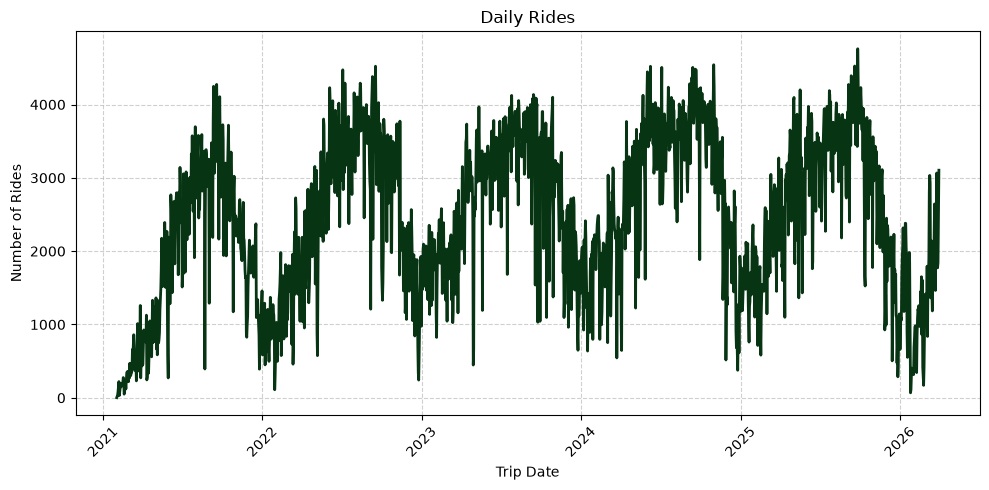

In [73]:
import matplotlib.pyplot as plt

daily_rides_df = (
    trips.withColumn("trip_date", to_date("started_at"))
    .groupBy("trip_date")
    .agg(count("*").alias("daily_rides"))
    .orderBy("trip_date")
)

pandas_df = daily_rides_df.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(
    pandas_df["trip_date"],
    pandas_df["daily_rides"],
    color="#073412",
    linewidth=2,
)

plt.title("Daily Rides")
plt.xlabel("Trip Date")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

In [74]:
trips.groupBy("member_casual", "rideable_type").agg(
    avg("rideDurationMinutes").alias("avg_ride_duration"),
    avg("rideDistanceKM").alias("avg_ride_distance"),
).show()

+-------------+-------------+------------------+------------------+
|member_casual|rideable_type| avg_ride_duration| avg_ride_distance|
+-------------+-------------+------------------+------------------+
|       casual| classic_bike|20.178052749024218|1.2393873560559767|
|       casual|electric_bike|14.848071589198865|1.3591016740191932|
|       member| classic_bike|  9.77054775703474|1.0567834573674288|
|       member|electric_bike| 7.611158945774665|1.2729093428645668|
|       casual|  docked_bike| 58.70306486561251|1.0697713337328805|
|       member|  docked_bike|13.427701432291672|1.0655729166667198|
+-------------+-------------+------------------+------------------+



#### Collect List

The `collect_list()` function in PySpark is used to aggregate values into a list for each group when using the `groupBy()` function. This is useful when you want to collect all values of a specific column into a single list for each group.

The syntax for the `collect_list()` function is as follows:

```python
from pyspark.sql.functions import collect_list

df.groupBy("column_name").agg(collect_list("another_column").alias("list_column"))
```

In [75]:
data4 = [
    ("Me", "Book1"),
    ("Me", "Book2"),
    ("You", "Book2"),
    ("You", "Book4"),
    ("Us", "Book1"),
]

schema4 = "user string, book string"

df4 = spark.createDataFrame(data4, schema4)

df4.show()

+----+-----+
|user| book|
+----+-----+
|  Me|Book1|
|  Me|Book2|
| You|Book2|
| You|Book4|
|  Us|Book1|
+----+-----+



In [76]:
df4.groupBy("user").agg(collect_list("book")).show()

+----+------------------+
|user|collect_list(book)|
+----+------------------+
|  Me|    [Book1, Book2]|
| You|    [Book2, Book4]|
|  Us|           [Book1]|
+----+------------------+



#### Pivoting Data

Pivoting data in PySpark allows you to transform rows into columns, making it easier to analyze and visualize data. The `pivot()` function is used in conjunction with `groupBy()` to achieve this transformation.

A simple example of using the `pivot()` function is as follows:

```python
df.groupBy("group_column").pivot("pivot_column").agg({"value_column": "aggregate_function"})
```

In [77]:
trips_updated.groupBy("rideable_type").pivot("member_casual").agg(
    avg("rideDurationMinutes").alias("avg_ride_duration")
).show()

+-------------+------------------+------------------+
|rideable_type|            casual|            member|
+-------------+------------------+------------------+
|  docked_bike| 58.70306486561251|13.427701432291672|
|electric_bike|14.848071589198865| 7.611158945774665|
| classic_bike|20.178052749024218|  9.77054775703474|
+-------------+------------------+------------------+



In [78]:
trips_updated.groupBy("member_casual").pivot("rideable_type").agg(
    avg("rideDistanceKM").alias("avg_ride_distance")
).show()

+-------------+------------------+------------------+------------------+
|member_casual|      classic_bike|       docked_bike|     electric_bike|
+-------------+------------------+------------------+------------------+
|       casual|1.2393873560559767|1.0697713337328805|1.3591016740191932|
|       member|1.0567834573674288|1.0655729166667198|1.2729093428645668|
+-------------+------------------+------------------+------------------+



#### When-Otherwise

This is a conditional expression in PySpark that allows you to create new columns based on certain conditions. The `when()` function is used to specify the condition, and the `otherwise()` function is used to specify the value to assign when the condition is not met.

A simple example of using the `when()` and `otherwise()` functions is as follows:

```python
from pyspark.sql.functions import when

df = df.withColumn("new_column", when(df["condition_column"] == "condition_value", "value_if_true").otherwise("value_if_false"))
```

In [79]:
trips_updated.withColumn(
    "trip_duration_flag",
    when(col("rideDurationMinutes") < 1, "Not possible").otherwise("Very possible"),
).show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+--------------------+------------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|          start_time|trip_duration_flag|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+------

In [80]:
trips_updated.withColumn(
    "trip_duration_flag",
    when(
        (col("rideDurationMinutes") < 1) & (col("rideDistanceM") < 1), "Buggy data"
    ).otherwise("Very possible"),
).show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+--------------------+------------------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|          start_time|trip_duration_flag|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+------

### JOINS

#### INNER JOIN

Inner Join returns values common in both data frames based on the join condition. It only includes rows that have matching values in both DataFrames.

The syntax for performing an inner join in PySpark is as follows:

```python
df1.join(df2, df1["join_column"] == df2["join_column"], "inner")
```

In [81]:
deps = [
    ("1", "gaur", "d01"),
    ("2", "pius", "d04"),
    ("3", "john", "d04"),
    ("4", "jane", "d04"),
    ("5", "james", "d05"),
    ("5", "james", "d06"),
]

schema_deps = """id string, emp_name string, dept_id string"""

deps_df = spark.createDataFrame(deps, schema_deps)

daps = [
    ("d01", "HR"),
    ("d02", "Marketing"),
    ("d03", "Finance"),
    ("d04", "IT"),
    ("d05", "Sales"),
]

schema_daps = """id string, department_name string"""

daps_df = spark.createDataFrame(daps, schema_daps)

In [82]:
# Inner Join

deps_df.join(daps_df, deps_df["dept_id"] == daps_df["id"], "inner").show()

+---+--------+-------+---+---------------+
| id|emp_name|dept_id| id|department_name|
+---+--------+-------+---+---------------+
|  1|    gaur|    d01|d01|             HR|
|  2|    pius|    d04|d04|             IT|
|  3|    john|    d04|d04|             IT|
|  4|    jane|    d04|d04|             IT|
|  5|   james|    d05|d05|          Sales|
+---+--------+-------+---+---------------+



#### LEFT JOIN

Left Join returns all values from the left DataFrame and the matching values from the right DataFrame based on the join condition. If there is no match, the result will contain null values for the right DataFrame's columns.

The syntax for performing a left join in PySpark is as follows:

```python
df1.join(df2, df1["join_column"] == df2["join_column"], "left")
```

In [83]:
deps_df.join(daps_df, deps_df["dept_id"] == daps_df["id"], how="left").show()

+---+--------+-------+----+---------------+
| id|emp_name|dept_id|  id|department_name|
+---+--------+-------+----+---------------+
|  1|    gaur|    d01| d01|             HR|
|  2|    pius|    d04| d04|             IT|
|  3|    john|    d04| d04|             IT|
|  4|    jane|    d04| d04|             IT|
|  5|   james|    d05| d05|          Sales|
|  5|   james|    d06|NULL|           NULL|
+---+--------+-------+----+---------------+



#### RIGHT JOIN

Right Join returns all values from the right DataFrame and the matching values from the left DataFrame based on the join condition. If there is no match, the result will contain null values for the left DataFrame's columns.

The syntax for performing a right join in PySpark is as follows:

```python
df1.join(df2, df1["join_column"] == df2["join_column"], "right")
```

In [84]:
daps_df.join(deps_df, daps_df["id"] == deps_df["dept_id"], how="right").show()

+----+---------------+---+--------+-------+
|  id|department_name| id|emp_name|dept_id|
+----+---------------+---+--------+-------+
| d01|             HR|  1|    gaur|    d01|
| d04|             IT|  2|    pius|    d04|
| d04|             IT|  3|    john|    d04|
| d04|             IT|  4|    jane|    d04|
| d05|          Sales|  5|   james|    d05|
|NULL|           NULL|  5|   james|    d06|
+----+---------------+---+--------+-------+



#### FULL OUTER JOIN / FULL JOIN

Full Outer Join returns all values from both DataFrames, including matching and non-matching rows. If there is no match, the result will contain null values for the columns of the DataFrame that does not have a matching row.

The syntax for performing a full outer join in PySpark is as follows:

```python
df1.join(df2, df1["join_column"] == df2["join_column"], "outer")
```

In [85]:
deps_df.join(daps_df, deps_df["dept_id"] == daps_df["id"], how="outer").show()

+----+--------+-------+----+---------------+
|  id|emp_name|dept_id|  id|department_name|
+----+--------+-------+----+---------------+
|   1|    gaur|    d01| d01|             HR|
|NULL|    NULL|   NULL| d02|      Marketing|
|NULL|    NULL|   NULL| d03|        Finance|
|   2|    pius|    d04| d04|             IT|
|   3|    john|    d04| d04|             IT|
|   4|    jane|    d04| d04|             IT|
|   5|   james|    d05| d05|          Sales|
|   5|   james|    d06|NULL|           NULL|
+----+--------+-------+----+---------------+



#### ANTI JOIN

Anti Join returns all values from the left DataFrame that do not have a matching value in the right DataFrame based on the join condition. It is useful for finding records in one DataFrame that do not exist in another.

The syntax for performing an anti join in PySpark is as follows:

```python
df1.join(df2, df1["join_column"] == df2["join_column"], "left_anti")
```

In [86]:
deps_df.join(daps_df, deps_df["dept_id"] == daps_df["id"], how="left_anti").show()

+---+--------+-------+
| id|emp_name|dept_id|
+---+--------+-------+
|  5|   james|    d06|
+---+--------+-------+



### Window Functions

Window Functions generally perform calculations across a set of table rows that are somehow related to the current row. They are often used for ranking, cumulative sums, moving averages, and other calculations that require context from surrounding rows.

They are also useful when `deduplicating` data, as they allow you to define a window of rows to consider for each calculation, rather than just looking at the entire DataFrame. This can be particularly useful when you want to perform calculations that are specific to a certain group or partition of data.

They include `row_number()`, `rank()`, `dense_rank()`, `lag()`, `lead()`, and many others. These functions can be used in conjunction with the `Window` specification to define the partitioning and ordering of the data for the calculations.

#### ROW_NUMBER()

A row number is a unique sequential integer assigned to rows within a partition of a result set. The row number starts at 1 for the first row in each partition.

The syntax for using the `row_number()` function in PySpark is as follows:

```python
from pyspark.sql.window import Window

df = df.withColumn("rowCol", row_number().over(Window.orderBy("column_name")))
```

In [87]:
from pyspark.sql.window import Window

trips_updated.withColumn(
    "rowCol", row_number().over(Window.orderBy("rideDurationMinutes"))
).show()  # Ascending order by default

26/07/10 11:05:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+--------------------+------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|        start_lat|         start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|          start_time|rowCol|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+-----------------+------------------+-----------------+------------------+-------------+-------------------+--

In [88]:
from pyspark.sql.window import Window

trips_updated.withColumn(
    "rowCol", row_number().over(Window.orderBy(col("rideDurationMinutes").desc()))
).show()  # Ascending order by default

26/07/10 11:05:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+--------------------+------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|start_lat| start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|          start_time|rowCol|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+---

#### RANK()

The `rank()` function assigns a unique rank to each row within a partition of a result set, with the same rank assigned to rows with equal values. The next rank is incremented by the number of tied rows.

The syntax for using the `rank()` function in PySpark is as follows:

```python
from pyspark.sql.window import Window

df = df.withColumn("rankCol", rank().over(Window.orderBy("column_name")))
```

In [89]:
trips_updated.withColumn(
    "rowCol", rank().over(Window.orderBy(desc("rideDurationMinutes")))
).show()  # Ascending order by default

26/07/10 11:05:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+--------------------+------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|start_lat| start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|          start_time|rowCol|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+---

#### DENSE_RANK()

Dense Rank is similar to the `rank()` function, but it does not leave gaps in the ranking sequence when there are ties. Rows with equal values receive the same rank, and the next rank is incremented by 1.

The syntax for using the `dense_rank()` function in PySpark is as follows:

```python
from pyspark.sql.window import Window

df = df.withColumn("denseRankCol", dense_rank().over(Window.orderBy("column_name")))
```

In [90]:
trips_updated.withColumn(
    "rowCol", dense_rank().over(Window.orderBy(desc("rideDurationMinutes")))
).show()  # Ascending order by default

26/07/10 11:05:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+------------+-----------+-----------+----+--------------------+------+
|         ride_id|rideable_type|         started_at|           ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|start_lat| start_lng|          end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|current_date|future_date|week_before|days|          start_time|rowCol|
+----------------+-------------+-------------------+-------------------+--------------------+----------------+--------------------+--------------+---------+----------+-----------------+------------------+-------------+-------------------+-----------------+--------------+-------------+---

#### LAG() and LEAD()

Lag and Lead are window functions that allow you to access data from previous or subsequent rows in a DataFrame, respectively. They are useful for comparing values across rows or calculating differences between rows.

Lag allows you to access data from a previous row, while Lead allows you to access data from a subsequent row. Both functions take two arguments: the column to access and the number of rows to look back or forward.

The syntax for using the `lag()` and `lead()` functions in PySpark is as follows:

```python
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, col

# Define the Window Specification
# Partitioning separates stores; ordering ensures sequence by date
windowSpec = Window.partitionBy("store").orderBy("date")

# Apply the lag function
result_df = df.withColumn("previous_day_sales", lag("sales", 1, 0).over(windowSpec))

# Calculate the day-over-day difference
final_df = result_df.withColumn("sales_variance", col("sales") - col("previous_day_sales"))

final_df.show()
```

In [91]:
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, col

data = [
    ("Store_A", "2026-01-01", 100),
    ("Store_A", "2026-01-02", 150),
    ("Store_A", "2026-01-03", 130),
    ("Store_B", "2026-01-01", 200),
    ("Store_B", "2026-01-02", 220),
]
columns = ["store", "date", "sales"]
df = spark.createDataFrame(data, columns)

# Define the Window Specification
# Partitioning separates stores; ordering ensures sequence by date
windowSpec = Window.partitionBy("store").orderBy("date")

# Apply the lag function
result_df = df.withColumn("previous_day_sales", lag("sales", 1, 0).over(windowSpec))

# 5. Calculate the day-over-day difference
final_df = result_df.withColumn(
    "sales_variance", col("sales") - col("previous_day_sales")
)

final_df.show()

+-------+----------+-----+------------------+--------------+
|  store|      date|sales|previous_day_sales|sales_variance|
+-------+----------+-----+------------------+--------------+
|Store_A|2026-01-01|  100|                 0|           100|
|Store_A|2026-01-02|  150|               100|            50|
|Store_A|2026-01-03|  130|               150|           -20|
|Store_B|2026-01-01|  200|                 0|           200|
|Store_B|2026-01-02|  220|               200|            20|
+-------+----------+-----+------------------+--------------+



In [92]:
# Lead function (Looking 1 row ahead, default to 0 if out of bounds)
result_df = df.withColumn("next_day_sales", lead("sales", 1, 0).over(windowSpec))

# Difference between current sales and next day's sales
final_df = result_df.withColumn(
    "sales_growth_needed", col("next_day_sales") - col("sales")
)

final_df.show()

+-------+----------+-----+--------------+-------------------+
|  store|      date|sales|next_day_sales|sales_growth_needed|
+-------+----------+-----+--------------+-------------------+
|Store_A|2026-01-01|  100|           150|                 50|
|Store_A|2026-01-02|  150|           130|                -20|
|Store_A|2026-01-03|  130|             0|               -130|
|Store_B|2026-01-01|  200|           220|                 20|
|Store_B|2026-01-02|  220|             0|               -220|
+-------+----------+-----+--------------+-------------------+



#### Cumulative Sum

Cumulative Sum is a window function that calculates the running total of a specified column over a defined window of rows. It is useful for analyzing trends and patterns in data over time.

The syntax for using the `cumsum()` function in PySpark is as follows:

```python
from pyspark.sql.window import Window
from pyspark.sql.functions import sum as _sum

# Define the Window Specification
windowSpec = Window.orderBy("column_name").rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Apply the cumulative sum function
df = df.withColumn("cumulative_sum", _sum("column_name").over(windowSpec))
```

In [93]:
windowSpec = (
    Window.orderBy("store")
    .orderBy("date")
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

result_df = df.withColumn("cumulative_sales", sum("sales").over(windowSpec)).show()

+-------+----------+-----+----------------+
|  store|      date|sales|cumulative_sales|
+-------+----------+-----+----------------+
|Store_A|2026-01-01|  100|             100|
|Store_B|2026-01-01|  200|             300|
|Store_A|2026-01-02|  150|             450|
|Store_B|2026-01-02|  220|             670|
|Store_A|2026-01-03|  130|             800|
+-------+----------+-----+----------------+



26/07/10 11:05:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:31 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [94]:
# Or - Shows total sales in all rows

df.withColumn(
    "totalsales",
    sum("sales").over(
        Window.orderBy("store").rowsBetween(
            Window.unboundedPreceding, Window.unboundedFollowing
        )
    ),
).show()

26/07/10 11:05:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+-------+----------+-----+----------+
|  store|      date|sales|totalsales|
+-------+----------+-----+----------+
|Store_A|2026-01-01|  100|       800|
|Store_A|2026-01-02|  150|       800|
|Store_A|2026-01-03|  130|       800|
|Store_B|2026-01-01|  200|       800|
|Store_B|2026-01-02|  220|       800|
+-------+----------+-----+----------+



26/07/10 11:05:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/07/10 11:05:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


### User Defined Functions (UDFs)

A User Defined Function (UDF) in PySpark allows you to create custom functions that can be applied to DataFrame columns. UDFs are useful when you need to perform operations that are not available in the built-in PySpark functions.

However, it is recommended to use built-in functions whenever possible, as they are optimized for performance and can take advantage of Spark's Catalyst optimizer. UDFs can introduce performance overhead, especially when dealing with large datasets.

The executors involved are generally JVM and Python processes. When a UDF is called, the data is serialized and sent from the JVM to the Python process, where the UDF is executed. The result is then serialized back to the JVM and returned to the DataFrame. This serialization and deserialization process can introduce significant overhead, especially for large datasets.

In [95]:
# Writing the function


def my_func(x):
    return x * x

In [96]:
# Registering the function as a udf

my_udf = udf(my_func)

In [97]:
df.withColumn("mynewcol", my_udf("sales")).show()

+-------+----------+-----+--------+
|  store|      date|sales|mynewcol|
+-------+----------+-----+--------+
|Store_A|2026-01-01|  100|   10000|
|Store_A|2026-01-02|  150|   22500|
|Store_A|2026-01-03|  130|   16900|
|Store_B|2026-01-01|  200|   40000|
|Store_B|2026-01-02|  220|   48400|
+-------+----------+-----+--------+



### Data Writing

DataFrames can be written to various formats such as CSV, JSON, Parquet, and more. The `write` method is used to save the DataFrame to a specified location.

To write data, PySpark provides the `DataFrameWriter` API, accessed via df.write. Here, we can chain methods to specify the format, mode, and path for writing the DataFrame. For example, to write a DataFrame to a Parquet file, you can use the following syntax:

```python
df.write.format("parquet").mode("overwrite").option("header", "true").save("path/to/output.parquet")
```

Writing models include:

- `overwrite`: Truncates the target folder entirely and replaces them with the new data. This is useful when you want to refresh the data completely.

```python
df.write.mode("overwrite").save("path/to/output")
```

- `append`: Adds new data to the existing data in the target folder. This is useful when you want to add incremental data without losing the existing data.

```python
df.write.mode("append").save("path/to/output")
```

- `error` or `errorifexists`: Raises an error if the target folder already exists. This is useful when you want to ensure that you do not accidentally overwrite existing data. This happens to be the default mode if no mode is specified.

```python
df.write.mode("error").save("path/to/output")
```

- `ignore`: Ignores the write operation if the target folder already exists. This is useful when you want to avoid overwriting existing data and do not want to raise an error.

```python
df.write.mode("ignore").save("path/to/output")
```

While we can write to basic formats like CSV and JSON, Big Data operations typically favor Columnar File Formats since they drastically improve query performance by allowing column-level pruning.

- `Parquet`: A columnar storage file format that is optimized for performance and storage efficiency. It is widely used in big data processing frameworks like Apache Spark and Apache Hive. Its metadata, like schema, is stored in the file footer, allowing for efficient reading and writing of data.

```python
df.write.format("parquet").mode("overwrite").save("path/to/output.parquet")
```

- `delta`: A storage layer that brings ACID transactions to Apache Spark and big data workloads. It provides features like schema evolution, time travel, and data versioning, making it suitable for building reliable and scalable data pipelines. Unlike standard Parquet files, Delta Lake maintains a transaction log that tracks changes to the data, enabling features like rollback and concurrent writes.

```python
df.write.format("delta").mode("overwrite").save("path/to/output.delta")
```

Instead of just saving raw files to a directory, we can register the DataFrame directly as a table in our catalog using the `saveAsTable()` method. This allows us to query the data using SQL syntax and manage it as a table in our Spark session.

```python
df.write.mode("overwrite").saveAsTable("table_name")
```

If we simply use `saveAsTable()` without providing a path, Databricks controls both the table metadata and the underlying data. If you `DROP` the table, the actual data files are permanently deleted. This is known as a `Managed Table`.

If we explicitly define a cloud storage location, such as passing an `.option("path", "s3://bucket_name/path/to/data")` to the `saveAsTable()` method, we can create an `External Table` and can manage the data. In this case, dropping the table will only remove the metadata, such as the schema definition from the catalog, but the actual data files will remain intact in the specified location.

```python
df.write.option("path", "s3://bucket_name/path/to/data").mode("overwrite").saveAsTable("table_name")
```

In [98]:
df.coalesce(1).write.format("csv").mode("overwrite").option("header", "true").save(
    "/Users/pius/Projects/analytics-engineering/Spark/data/df_output"
)

print("Done!")

Done!


### Spark SQL

In [99]:
trips.createOrReplaceTempView("trips")

query = """select * from trips where rideDurationHours > 1"""

spark.sql(query).show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+------------------+------------------+-------------+-------------------+-----------------+--------------+-------------+----------+----------+--------+----------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|         start_lat|         start_lng|           end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|start_time|start_date|end_time|  end_date|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+------------------+------------------+-------------+-------------------+-----------------+--------------+-------------

In [101]:
# Saving to a df

long_trips = spark.sql(query)

long_trips.show()

+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+------------------+------------------+-------------+-------------------+-----------------+--------------+-------------+----------+----------+--------+----------+
|         ride_id|rideable_type|          started_at|            ended_at|  start_station_name|start_station_id|    end_station_name|end_station_id|         start_lat|         start_lng|           end_lat|           end_lng|member_casual|rideDurationMinutes|rideDurationHours|rideDistanceKM|rideDistanceM|start_time|start_date|end_time|  end_date|
+----------------+-------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------+------------------+------------------+------------------+------------------+-------------+-------------------+-----------------+--------------+-------------